In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/train.csv")

In [3]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.shape

(913000, 4)

In [5]:
df.columns

Index(['date', 'store', 'item', 'sales'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [7]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [8]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [9]:
df['date'] = pd.to_datetime(df['date'])

df['weekday'] = df['date'].dt.day_name()

df.head()

,date,store,item,sales,weekday
0,2013-01-01,1,1,13,Tuesday
1,2013-01-02,1,1,11,Wednesday
2,2013-01-03,1,1,14,Thursday
3,2013-01-04,1,1,13,Friday
4,2013-01-05,1,1,10,Saturday


In [10]:
df['sold_quantity'] = df['sales']

df.head()

,date,store,item,sales,weekday,sold_quantity
0,2013-01-01,1,1,13,Tuesday,13
1,2013-01-02,1,1,11,Wednesday,11
2,2013-01-03,1,1,14,Thursday,14
3,2013-01-04,1,1,13,Friday,13
4,2013-01-05,1,1,10,Saturday,10


In [11]:
df = df.sort_values(['store', 'item', 'date'])

df.head()

,date,store,item,sales,weekday,sold_quantity
0,2013-01-01,1,1,13,Tuesday,13
1,2013-01-02,1,1,11,Wednesday,11
2,2013-01-03,1,1,14,Thursday,14
3,2013-01-04,1,1,13,Friday,13
4,2013-01-05,1,1,10,Saturday,10


In [12]:
df['avg_previous_sales'] = df.groupby(['store', 'item'])['sold_quantity'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

df.head(10)

,date,store,item,sales,weekday,sold_quantity,avg_previous_sales
0,2013-01-01,1,1,13,Tuesday,13,NaN
1,2013-01-02,1,1,11,Wednesday,11,NaN
2,2013-01-03,1,1,14,Thursday,14,NaN
3,2013-01-04,1,1,13,Friday,13,NaN
4,2013-01-05,1,1,10,Saturday,10,NaN
5,2013-01-06,1,1,12,Sunday,12,NaN
6,2013-01-07,1,1,10,Monday,10,NaN
7,2013-01-08,1,1,9,Tuesday,9,11.857143
8,2013-01-09,1,1,12,Wednesday,12,11.285714
9,2013-01-10,1,1,9,Thursday,9,11.428571


In [13]:
df = df.dropna(subset=['avg_previous_sales'])

df['prepared_quantity'] = np.ceil(df['avg_previous_sales'] * 1.15).astype(int)

df['prepared_quantity'] = df['prepared_quantity'].clip(lower=1)

df.head()

,date,store,item,sales,weekday,sold_quantity,avg_previous_sales,prepared_quantity
7,2013-01-08,1,1,9,Tuesday,9,11.857143,14
8,2013-01-09,1,1,12,Wednesday,12,11.285714,13
9,2013-01-10,1,1,9,Thursday,9,11.428571,14
10,2013-01-11,1,1,9,Friday,9,10.714286,13
11,2013-01-12,1,1,7,Saturday,7,10.142857,12


In [14]:
df['leftover_quantity'] = df['prepared_quantity'] - df['sold_quantity']

df['leftover_quantity'] = df['leftover_quantity'].clip(lower=0)

df['leftover_percentage'] = df['leftover_quantity'] / df['prepared_quantity']

df.head()

,date,store,item,sales,weekday,sold_quantity,avg_previous_sales,prepared_quantity,leftover_quantity,leftover_percentage
7,2013-01-08,1,1,9,Tuesday,9,11.857143,14,5,0.357143
8,2013-01-09,1,1,12,Wednesday,12,11.285714,13,1,0.076923
9,2013-01-10,1,1,9,Thursday,9,11.428571,14,5,0.357143
10,2013-01-11,1,1,9,Friday,9,10.714286,13,4,0.307692
11,2013-01-12,1,1,7,Saturday,7,10.142857,12,5,0.416667


In [15]:
def label_waste_risk(value):
    if value <= 0.10:
        return 'low'
    elif value <= 0.25:
        return 'medium'
    else:
        return 'high'

df['risk_label'] = df['leftover_percentage'].apply(label_waste_risk)

df.head()

,date,store,item,sales,weekday,sold_quantity,avg_previous_sales,prepared_quantity,leftover_quantity,leftover_percentage,risk_label
7,2013-01-08,1,1,9,Tuesday,9,11.857143,14,5,0.357143,high
8,2013-01-09,1,1,12,Wednesday,12,11.285714,13,1,0.076923,low
9,2013-01-10,1,1,9,Thursday,9,11.428571,14,5,0.357143,high
10,2013-01-11,1,1,9,Friday,9,10.714286,13,4,0.307692,high
11,2013-01-12,1,1,7,Saturday,7,10.142857,12,5,0.416667,high


In [16]:
df[['date', 'store', 'item', 'weekday', 'sold_quantity', 'prepared_quantity', 
    'leftover_quantity', 'leftover_percentage', 'risk_label']].head()

,date,store,item,weekday,sold_quantity,prepared_quantity,leftover_quantity,leftover_percentage,risk_label
7,2013-01-08,1,1,Tuesday,9,14,5,0.357143,high
8,2013-01-09,1,1,Wednesday,12,13,1,0.076923,low
9,2013-01-10,1,1,Thursday,9,14,5,0.357143,high
10,2013-01-11,1,1,Friday,9,13,4,0.307692,high
11,2013-01-12,1,1,Saturday,7,12,5,0.416667,high


In [17]:
df['risk_label'].value_counts()

risk_label
low       371000
medium    292961
high      245539
Name: count, dtype: int64

In [18]:
df['category'] = df['item']

X = df[['category', 'prepared_quantity', 'weekday']]
y = df['risk_label']

X.head()

,category,prepared_quantity,weekday
7,1,14,Tuesday
8,1,13,Wednesday
9,1,14,Thursday
10,1,13,Friday
11,1,12,Saturday


In [19]:
y.head()

7     high
8      low
9     high
10    high
11    high
Name: risk_label, dtype: object

In [20]:
X_encoded = pd.get_dummies(X, columns=['category', 'weekday'])

X_encoded.head()

,prepared_quantity,category_1,category_2,category_3,category_4,category_5,category_6,category_7,category_8,category_9,...,category_48,category_49,category_50,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday
7,14,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
8,13,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9,14,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
10,13,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
11,12,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (727600, 58)
X_test shape: (181900, 58)
y_train shape: (727600,)
y_test shape: (181900,)


In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
baseline_model = DummyClassifier(strategy='most_frequent')

baseline_model.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [25]:
baseline_predictions = baseline_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [27]:
print("Baseline Model Results")

print("Accuracy:", accuracy_score(y_test, baseline_predictions))
print("Precision:", precision_score(y_test, baseline_predictions, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, baseline_predictions, average='weighted'))
print("F1-score:", f1_score(y_test, baseline_predictions, average='weighted'))

Baseline Model Results
Accuracy: 0.4079164376030786
Precision: 0.16639582006678633
Recall: 0.4079164376030786
F1-score: 0.23637172721709046


In [28]:
labels = ['low', 'medium', 'high']

baseline_cm = confusion_matrix(y_test, baseline_predictions, labels=labels)

baseline_cm

array([[74200,     0,     0],
       [58592,     0,     0],
       [49108,     0,     0]])

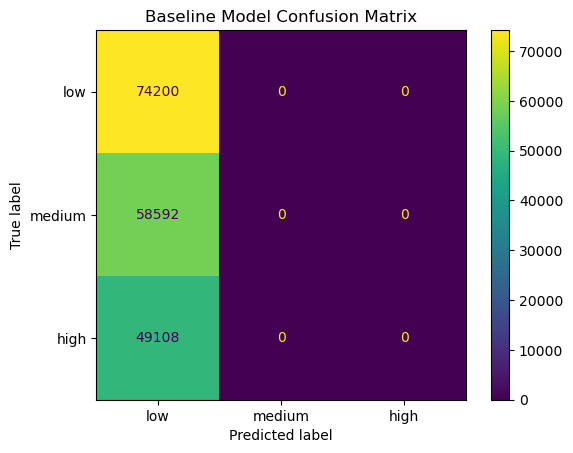

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=labels)

disp.plot()
plt.title("Baseline Model Confusion Matrix")
plt.show()

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

In [32]:
decision_tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
decision_tree_predictions = decision_tree_model.predict(X_test)

In [34]:
print("Decision Tree Model Results")

print("Accuracy:", accuracy_score(y_test, decision_tree_predictions))
print("Precision:", precision_score(y_test, decision_tree_predictions, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, decision_tree_predictions, average='weighted'))
print("F1-score:", f1_score(y_test, decision_tree_predictions, average='weighted'))

Decision Tree Model Results
Accuracy: 0.5608631115997801
Precision: 0.5480403307439567
Recall: 0.5608631115997801
F1-score: 0.5502395356699253


In [35]:
decision_tree_cm = confusion_matrix(y_test, decision_tree_predictions, labels=labels)

decision_tree_cm

array([[54893, 12023,  7284],
       [23421, 20410, 14761],
       [ 9729, 12661, 26718]])

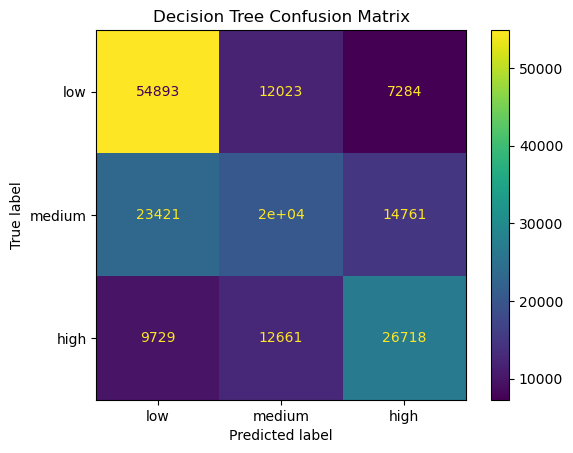

In [36]:
disp = ConfusionMatrixDisplay(confusion_matrix=decision_tree_cm, display_labels=labels)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
random_forest_model = RandomForestClassifier(random_state=42)

In [39]:
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
random_forest_predictions = random_forest_model.predict(X_test)

In [41]:
print("Random Forest Model Results")

print("Accuracy:", accuracy_score(y_test, random_forest_predictions))
print("Precision:", precision_score(y_test, random_forest_predictions, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, random_forest_predictions, average='weighted'))
print("F1-score:", f1_score(y_test, random_forest_predictions, average='weighted'))

Random Forest Model Results
Accuracy: 0.5612754260582737
Precision: 0.5505816533258115
Recall: 0.5612754260582737
F1-score: 0.5529743332813385


In [42]:
random_forest_cm = confusion_matrix(y_test, random_forest_predictions, labels=labels)

random_forest_cm

array([[54296, 13114,  6790],
       [22887, 21823, 13882],
       [ 9563, 13568, 25977]])

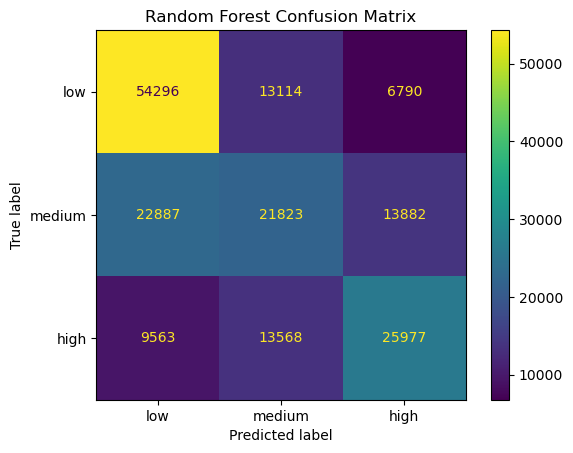

In [43]:
disp = ConfusionMatrixDisplay(confusion_matrix=random_forest_cm, display_labels=labels)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [44]:
baseline_results = {
    'Model': 'Baseline',
    'Accuracy': accuracy_score(y_test, baseline_predictions),
    'Precision': precision_score(y_test, baseline_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, baseline_predictions, average='weighted'),
    'F1-score': f1_score(y_test, baseline_predictions, average='weighted')
}

baseline_results

{'Model': 'Baseline',
 'Accuracy': 0.4079164376030786,
 'Precision': 0.16639582006678633,
 'Recall': 0.4079164376030786,
 'F1-score': 0.23637172721709046}

In [45]:
decision_tree_results = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, decision_tree_predictions),
    'Precision': precision_score(y_test, decision_tree_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, decision_tree_predictions, average='weighted'),
    'F1-score': f1_score(y_test, decision_tree_predictions, average='weighted')
}

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.5608631115997801,
 'Precision': 0.5480403307439567,
 'Recall': 0.5608631115997801,
 'F1-score': 0.5502395356699253}

In [46]:
random_forest_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, random_forest_predictions),
    'Precision': precision_score(y_test, random_forest_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, random_forest_predictions, average='weighted'),
    'F1-score': f1_score(y_test, random_forest_predictions, average='weighted')
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.5612754260582737,
 'Precision': 0.5505816533258115,
 'Recall': 0.5612754260582737,
 'F1-score': 0.5529743332813385}

In [47]:
model_results = pd.DataFrame([
    baseline_results,
    decision_tree_results,
    random_forest_results
])

model_results

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,0.407916,0.166396,0.407916,0.236372
1,Decision Tree,0.560863,0.548040,0.560863,0.550240
2,Random Forest,0.561275,0.550582,0.561275,0.552974


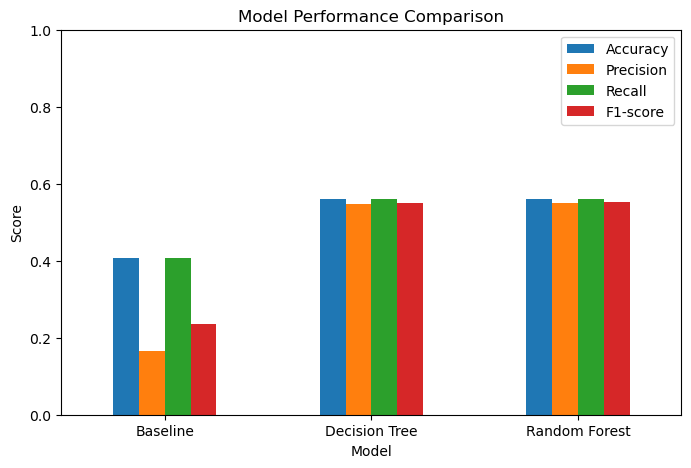

In [48]:
model_results.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1-score'],
    kind='bar',
    figsize=(8, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()